# House Prices - Advanced Regression Techniques

Importamos la información

In [92]:
import pandas as pd

df_prueba = pd.read_csv("test.csv")
df_entrenamiento = pd.read_csv("train.csv")

In [93]:
df_entrenamiento.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [94]:
nulos = df_entrenamiento.isnull().sum().sort_values()
nulos[nulos>0]

Electrical         1
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
BsmtFinType2      38
BsmtExposure      38
GarageQual        81
GarageFinish      81
GarageYrBlt       81
GarageType        81
GarageCond        81
LotFrontage      259
FireplaceQu      690
MasVnrType       872
Fence           1179
Alley           1369
MiscFeature     1406
PoolQC          1453
dtype: int64

El dataframe tiene *43 campos tipo cualitativo, 35 tipo cuantitativo discreto y 3 cuantitativo continuo*

## Contexto

- Precio de Venta: el precio de venta de la propiedad en dólares. Esta es la - variable objetivo que intenta predecir. MSSubClass: La clase de edificación

- MSZoning: La clasificación general de zonificación

- LotFrontage: Metros lineales de la calle conectada a la propiedad

- LotArea: Tamaño del lote en metros cuadrados

- Street: Tipo de acceso por carretera

- Alley: Tipo de acceso por callejón

- LotShape: Forma general de la propiedad

- LandContour: Planitud de la propiedad

- Utilities: Tipo de servicios públicos disponibles

- LotConfig: Configuración del lote

- LandSlope: Pendiente de la propiedad

- Neighborhood: Ubicaciones físicas dentro de los límites de la ciudad de Ames

- Condition1: Proximidad a la carretera principal o vía férrea

- Condition2: Proximidad a la carretera principal o vía férrea (si hay una segunda)

- BldgType: Tipo de vivienda

- HouseStyle: Estilo de la vivienda

- OverallQual: Calidad general de los materiales y acabados

- OverallCond: Calificación general del estado

- YearBuilt: Fecha de construcción original

- YearRemodAdd: Fecha de remodelación

- RoofStyle: Tipo de techo

- RoofMatl: Material del techo

- Exterior1st: Revestimiento exterior Casa

- Exterior2nd: Revestimiento exterior de la casa (si hay más de un material)

- MasVnrType: Tipo de revestimiento de mampostería

- MasVnrArea: Área de revestimiento de mampostería en pies cuadrados

- ExterQual: Calidad del material exterior

- ExterCond: Estado actual del material en el exterior

- Foundation: Tipo de cimiento

- BsmtQual: Altura del sótano

- BsmtCond: Estado general del sótano

- BsmtExposure: Muros del sótano a nivel del jardín o del acceso al exterior

- BsmtFinType1: Calidad del área terminada del sótano

- BsmtFinSF1: Superficie terminada tipo 1

- BsmtFinType2: Calidad de la segunda área terminada (si la hay)

- BsmtFinSF2: Superficie terminada tipo 2

- BsmtUnfSF: Superficie sin terminar del sótano

- TotalBsmtSF: Superficie total del sótano

- Heating: Tipo de calefacción

- HeatingQC: Calidad de la calefacción y Estado

- Aire acondicionado central: Aire acondicionado central

- Electricidad: Sistema eléctrico

- 1.er piso: Superficie del primer piso 

- 2.º piso: Superficie del segundo piso

- LowQualFinSF: Superficie con acabados de baja calidad (todas las plantas)

- GrLivArea: Superficie habitable sobre rasante (planta baja)

- BsmtFullBath: Baños completos en el sótano

- BsmtHalfBath: Medios baños en el sótano

- FullBath: Baños completos sobre rasante

- HalfBath: Medios baños sobre rasante

- Bedroom: Número de dormitorios sobre el nivel del sótano

- Kitchen: Número de cocinas

- KitchenQual: Calidad de la cocina

- TotRmsAbvGrd: Total de habitaciones sobre rasante (no incluye baños)

- Functional: Calificación de funcionalidad de la vivienda

- Chimeneas: Número de chimeneas

- FireplaceQu: Calidad de la chimenea

- GarageType: Ubicación del garaje

- GarageYrBlt: Año de construcción del garaje

- GarageFinish: Acabado interior del garaje

- GarageCars: Tamaño del garaje en el coche Capacidad

- GarageArea: Superficie del garaje en pies cuadrados

- GarageQual: Calidad del garaje

- GarageCond: Estado del garaje

- PavedDrive: Entrada pavimentada

- WoodDeckSF: Superficie de la terraza de madera en pies cuadrados

- OpenPorchSF: Superficie del porche abierto en pies cuadrados

- EnclosedPorch: Superficie del porche cerrado en pies cuadrados

- 3SsnPorch: Superficie del porche para tres estaciones en pies cuadrados

- ScreenPorch: Superficie del porche con mosquitero en pies cuadrados

- PoolArea: Superficie de la piscina en pies cuadrados

- PoolQC: Calidad de la piscina

- Fence: Calidad de la cerca

- MiscFeature: Característica miscelánea no incluida en otras categorías

- MiscVal: Valor en dólares de la característica miscelánea

- MoSold: Mes de venta

- YrSold: Año de venta

- SaleType: Tipo de venta

- SaleCondition: Estado de venta

Determinamos los mejores atributos para realizar el análisis

- Utilities
- OverallQual
- OverallCond
- ExterQual
- ExterCond
- GrLivArea
- FullBath
- KitchenQual
- GarageCars
- Bedroom
- TotRmsAbvGrd

Otras caracteristicas indirectas:
- SaleType
- Sale Condition


Filtramos para estos atributos

In [95]:
df_entrenamiento.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [96]:
df_entrenamiento_filtrado = df_entrenamiento[['Utilities',
                                              'OverallQual',
                                              'OverallCond',
                                              'ExterQual',
                                              'ExterCond',
                                              'GrLivArea',
                                              'FullBath',
                                              'KitchenQual',
                                              'GarageCars',
                                              'BedroomAbvGr',
                                              'TotRmsAbvGrd',
                                              'SalePrice']]

df_entrenamiento_filtrado.info()

df_entrenamiento_filtrado.isnull().sum().sort_values()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Utilities     1460 non-null   object
 1   OverallQual   1460 non-null   int64 
 2   OverallCond   1460 non-null   int64 
 3   ExterQual     1460 non-null   object
 4   ExterCond     1460 non-null   object
 5   GrLivArea     1460 non-null   int64 
 6   FullBath      1460 non-null   int64 
 7   KitchenQual   1460 non-null   object
 8   GarageCars    1460 non-null   int64 
 9   BedroomAbvGr  1460 non-null   int64 
 10  TotRmsAbvGrd  1460 non-null   int64 
 11  SalePrice     1460 non-null   int64 
dtypes: int64(8), object(4)
memory usage: 137.0+ KB


Utilities       0
OverallQual     0
OverallCond     0
ExterQual       0
ExterCond       0
GrLivArea       0
FullBath        0
KitchenQual     0
GarageCars      0
BedroomAbvGr    0
TotRmsAbvGrd    0
SalePrice       0
dtype: int64

Nuestro subdataframe contiene **4 campos cualitativos y 8 cuantitativos discretos**

In [97]:
df_entrenamiento_filtrado[['OverallQual','OverallCond']]
Overall_Cond_Qual = df_entrenamiento_filtrado['OverallQual'] - df_entrenamiento_filtrado['OverallCond']
Overall_Cond_Qual

0       2
1      -2
2       2
3       2
4       3
       ..
1455    1
1456    0
1457   -2
1458   -1
1459   -1
Length: 1460, dtype: int64

Al realizar una exploración del *df_entrenamiento_filtrado* en el datawrangler, el campo *Utilities* tiene un 99% de valores iguales, por lo que no aportará información

In [98]:
df_entrenamiento_filtrado.drop('Utilities', axis = 1, inplace = True)

C:\Users\52473\AppData\Local\Temp\ipykernel_20248\2753519538.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_entrenamiento_filtrado.drop('Utilities', axis = 1, inplace = True)


Realizamos una visualización de los datos

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

Cuantitativos

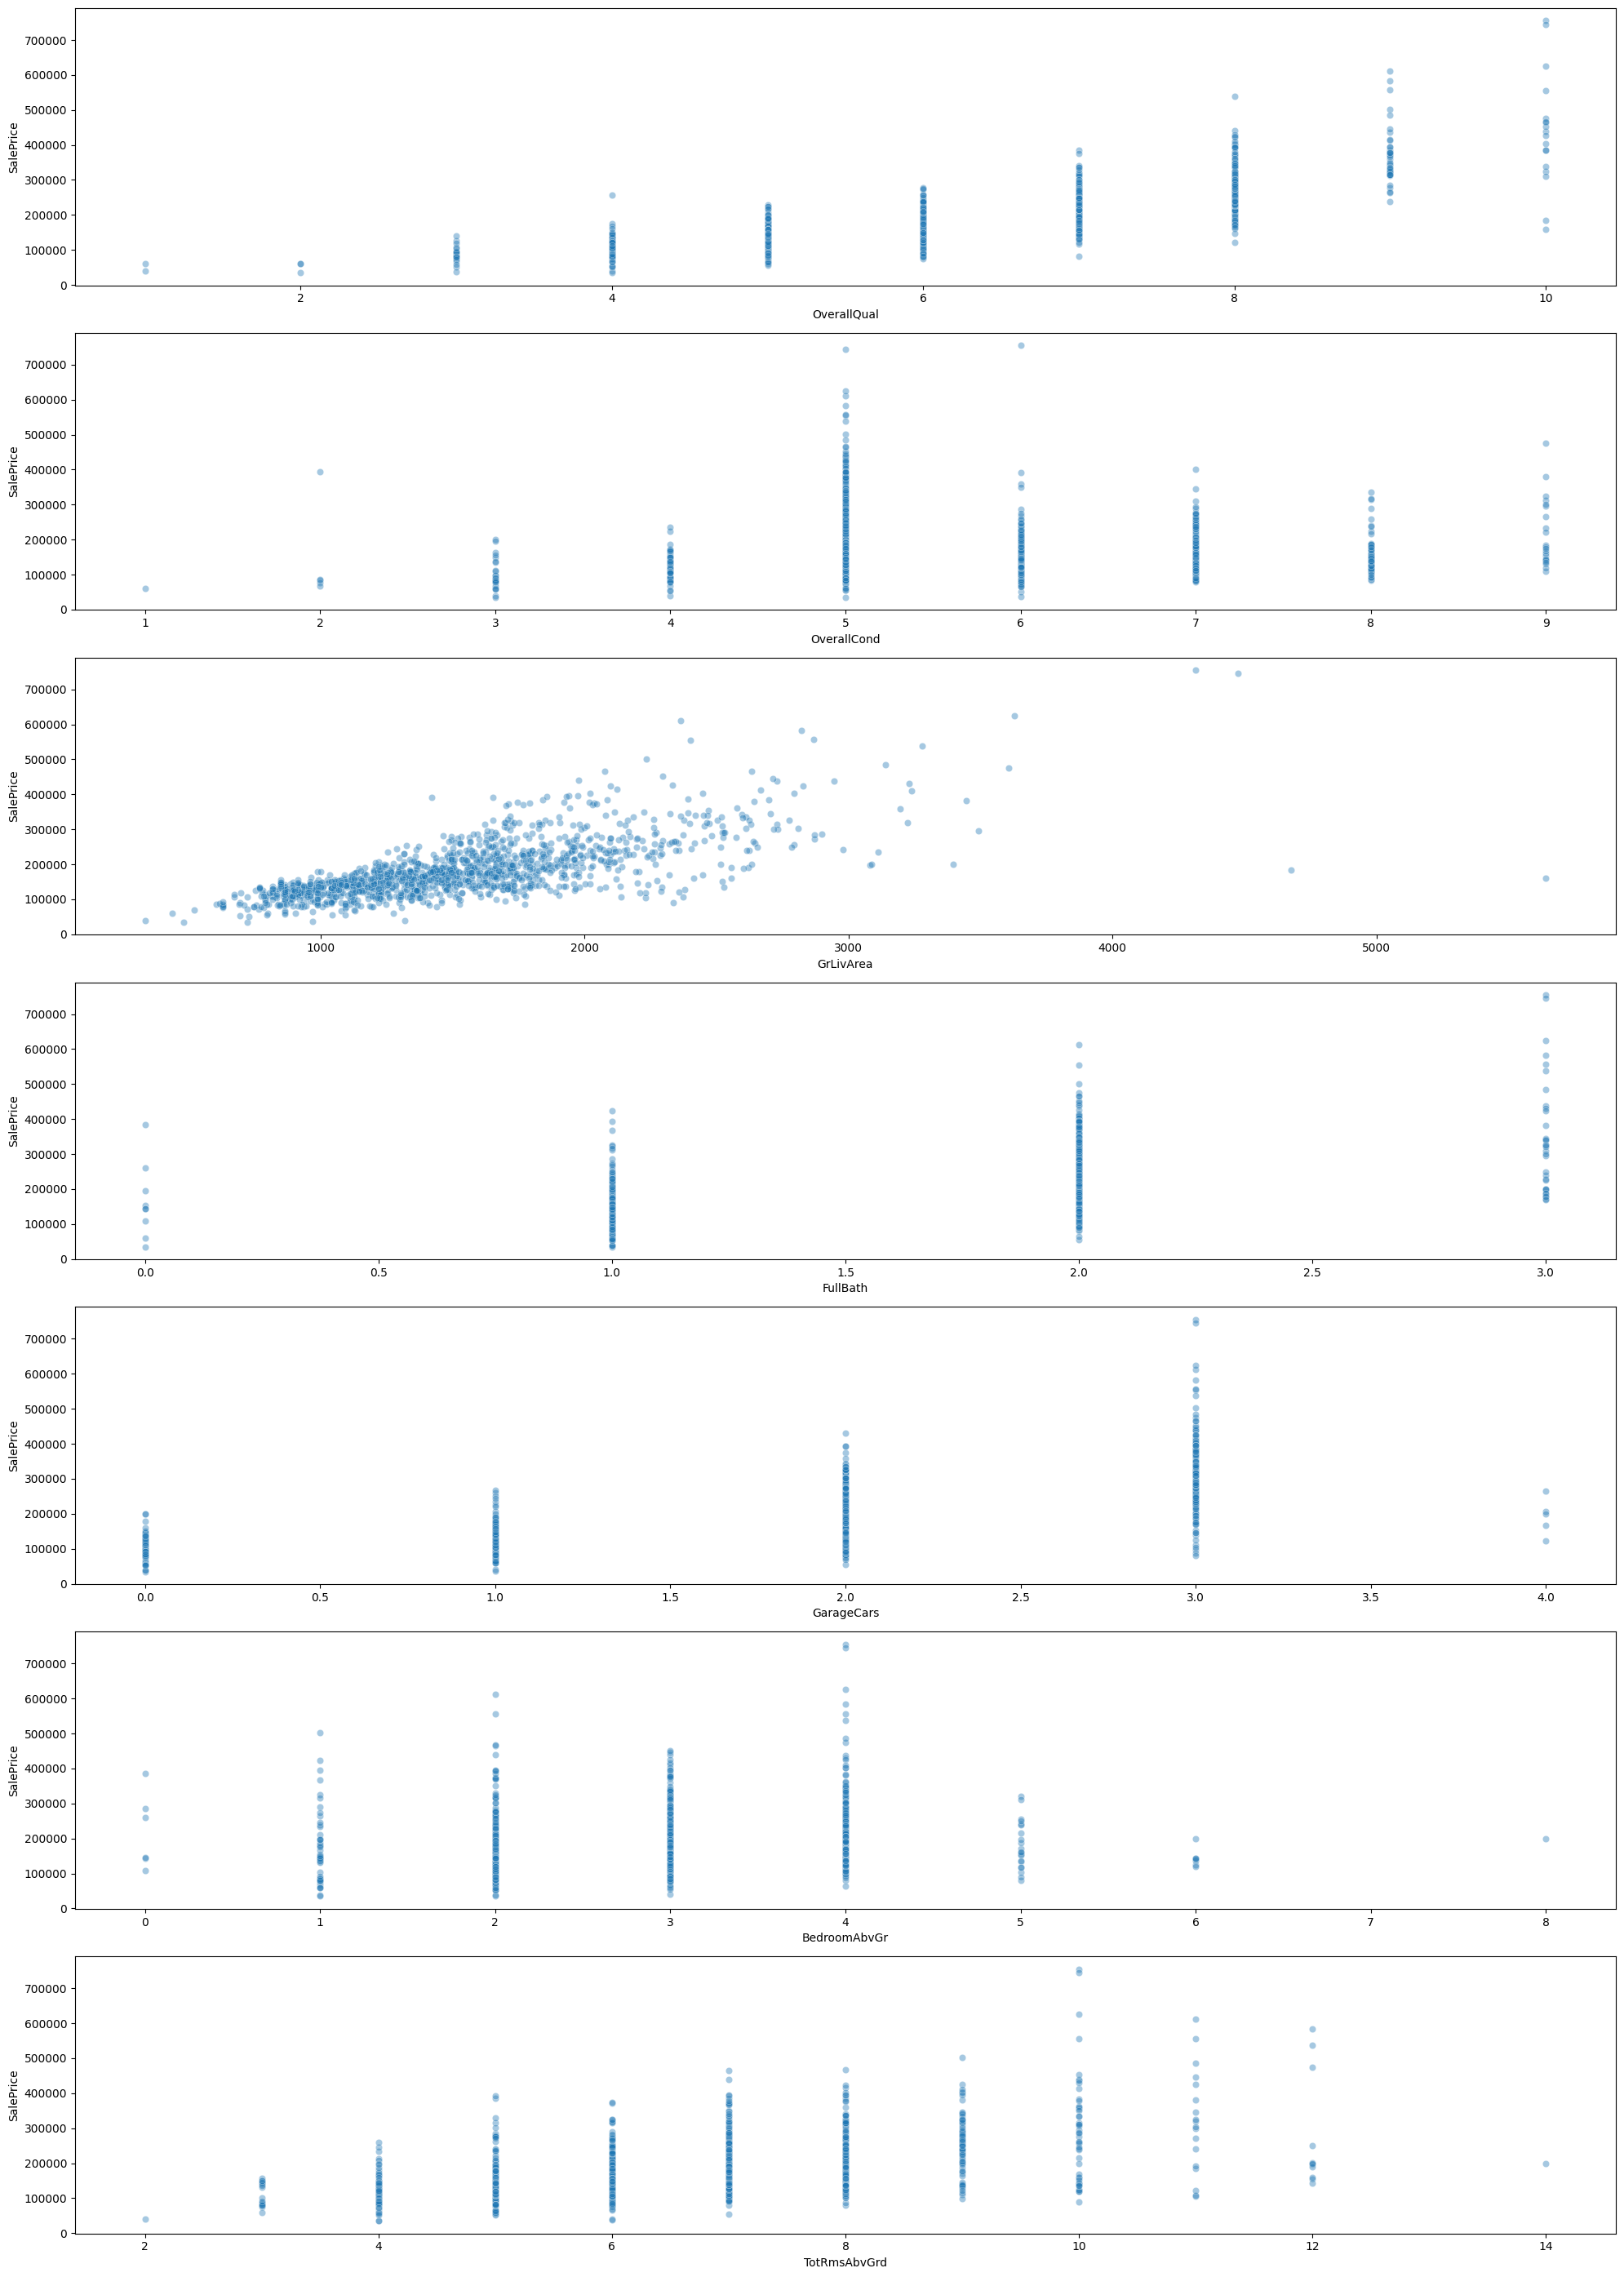

In [100]:
atributos_cuantitativos = ['OverallQual','OverallCond','GrLivArea','FullBath','GarageCars', 'BedroomAbvGr' , 'TotRmsAbvGrd']
n_col = 1
n_rows = math.ceil(len(atributos_cuantitativos)/n_col)

fig, axes = plt.subplots(n_rows,n_col, figsize = (20, n_rows*4))
axes = axes.flatten()

for j, col in enumerate(atributos_cuantitativos):
    sns.scatterplot(data = df_entrenamiento_filtrado, x = col , y = 'SalePrice', ax = axes[j], alpha = 0.4)
    


for j in range(j+1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

Para los datos cuantitativos discretos, vemos otra forma de visualización, y para el cuantitativo continuo acotamos los datos y graficamos tendencias.

No existen valores nulos pero los valores en 0 se pueden considerar en cierta forma como nulos y eso puede generar ruido

In [101]:
# Tratamiento

#OverAllCond
df_entrenamiento_filtrado = df_entrenamiento_filtrado[df_entrenamiento['OverallCond'] > 1]
  

#GrLivArea
df_entrenamiento_filtrado = df_entrenamiento_filtrado[df_entrenamiento_filtrado['GrLivArea'] <= 2800]

#FullBath & GarageCars & BedroomAbvGr
df_entrenamiento_filtrado = df_entrenamiento_filtrado[(df_entrenamiento_filtrado['FullBath'] != 0) & 
                                                      (df_entrenamiento_filtrado['GarageCars'] != 0) &
                                                      (df_entrenamiento_filtrado['BedroomAbvGr'] != 0)]




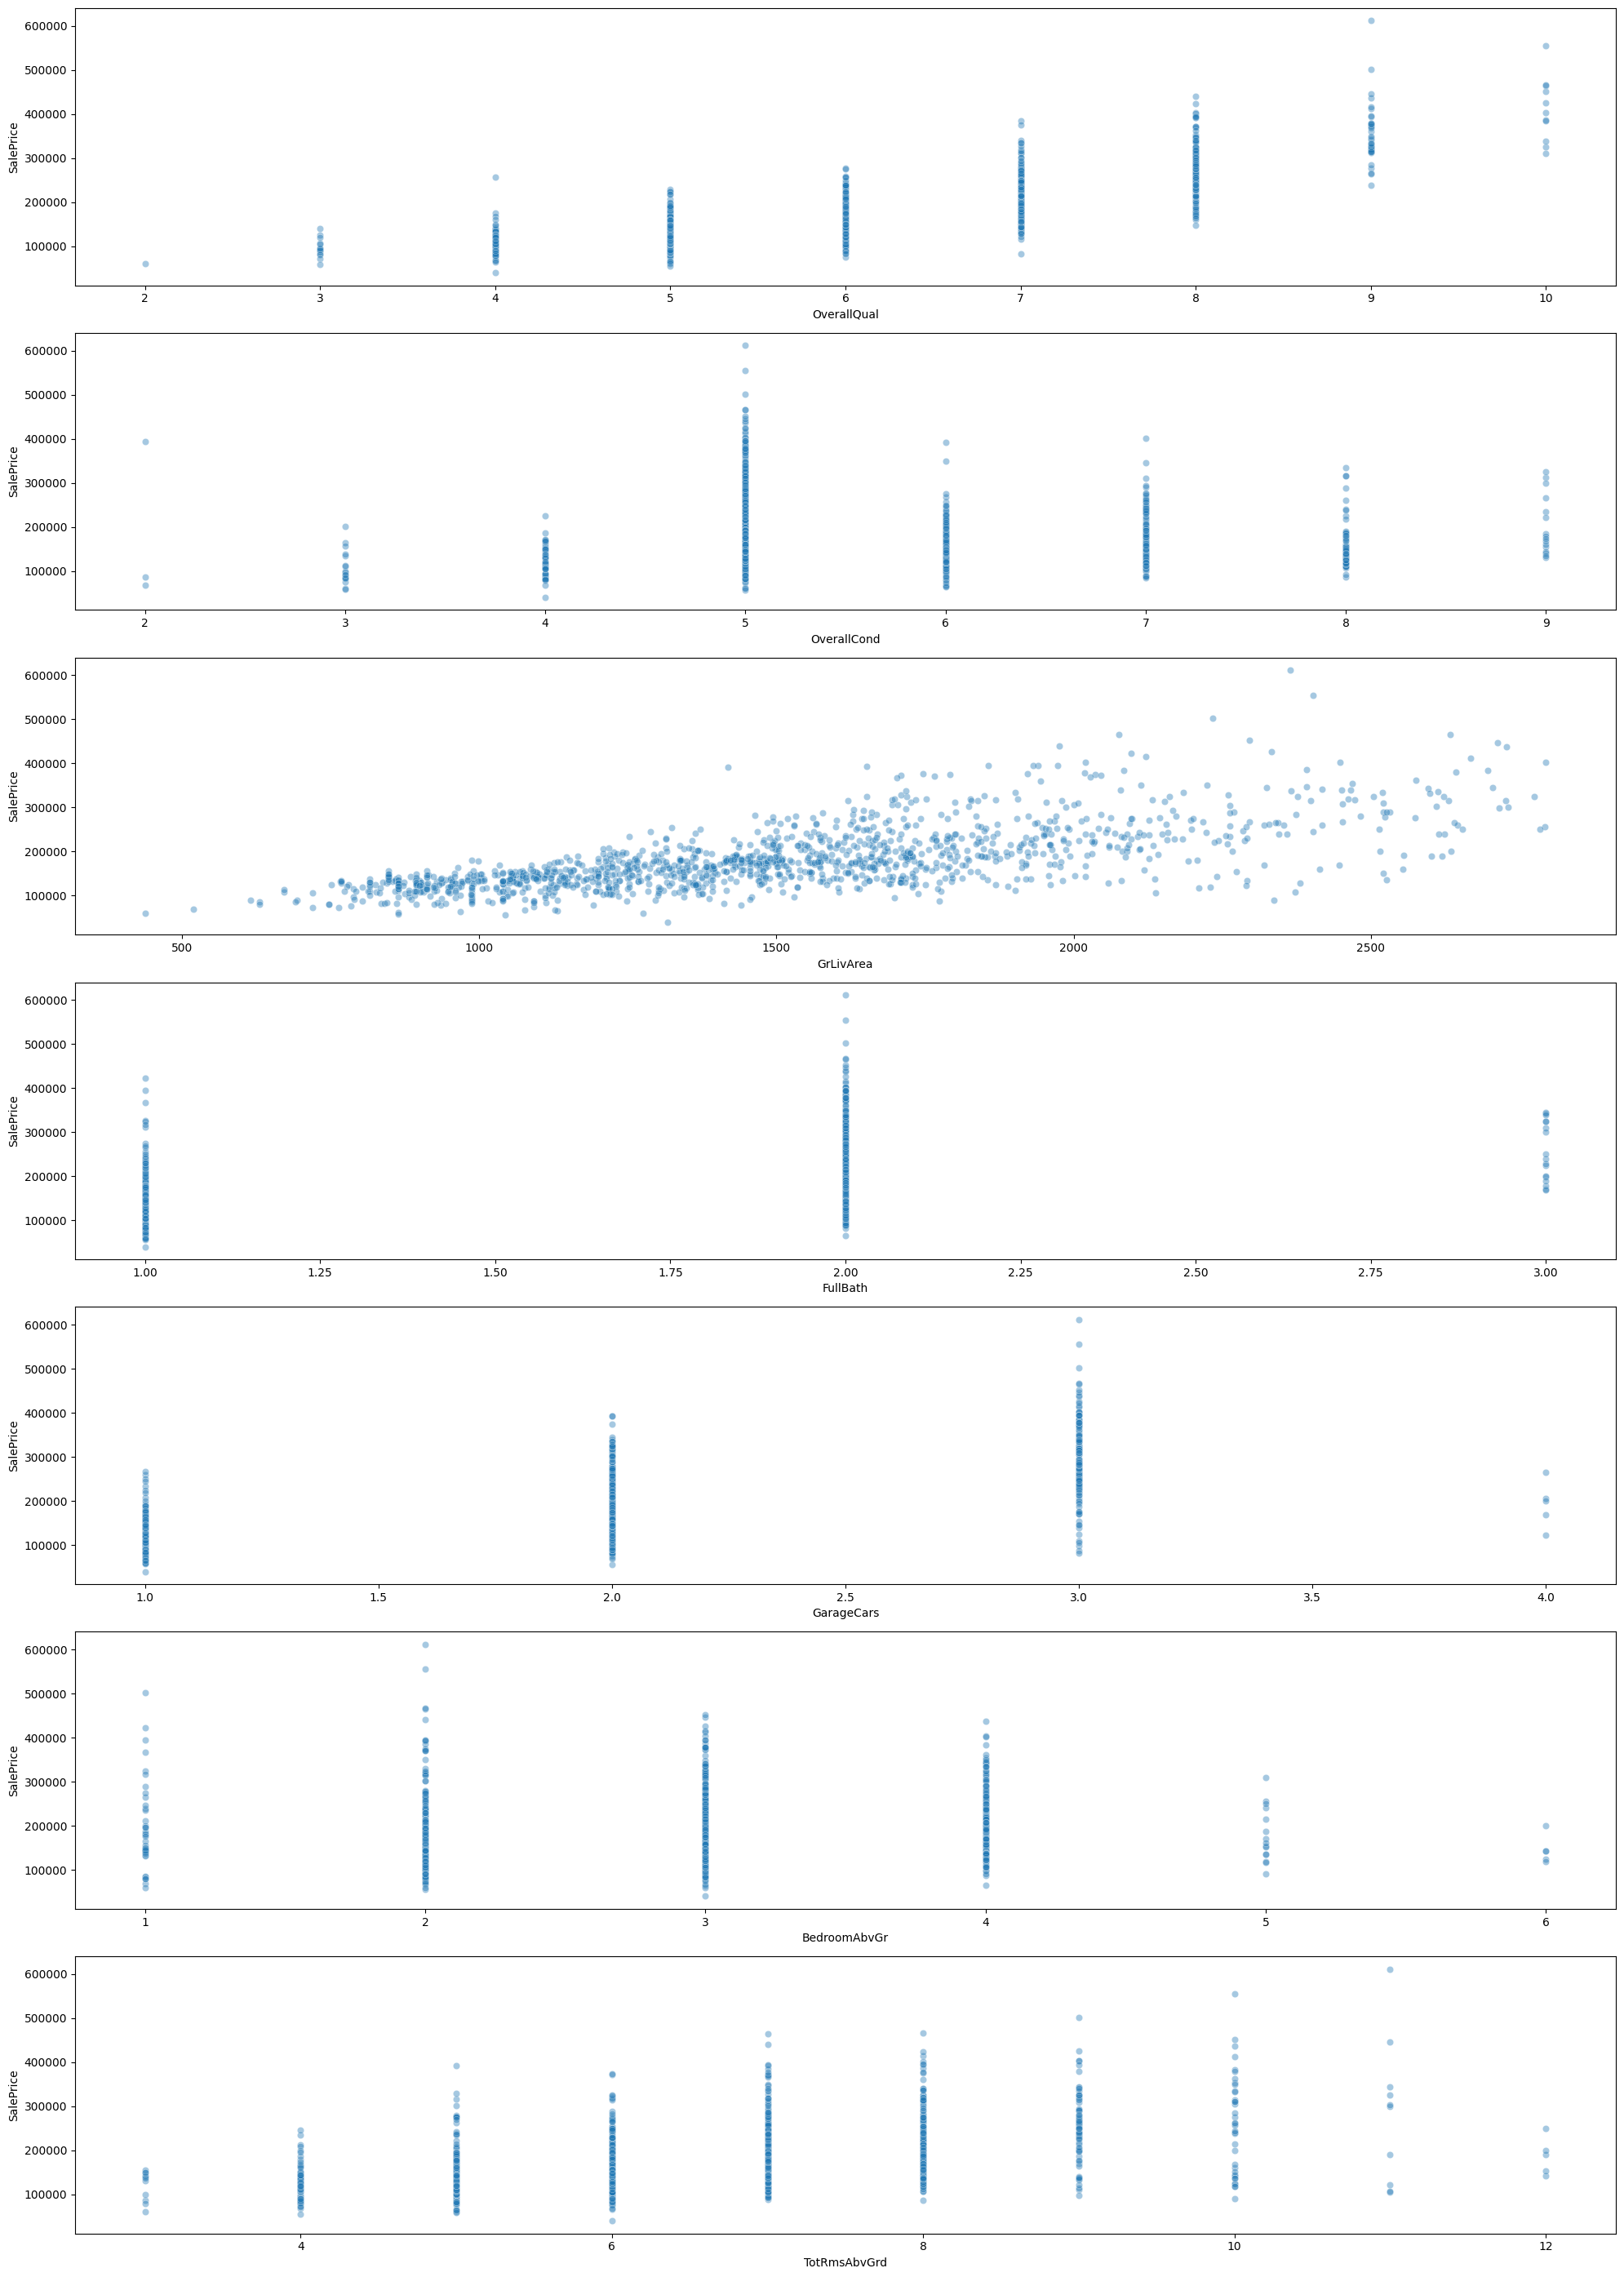

In [102]:
atributos_cuantitativos = ['OverallQual','OverallCond','GrLivArea','FullBath','GarageCars', 'BedroomAbvGr' , 'TotRmsAbvGrd']
n_col = 1
n_rows = math.ceil(len(atributos_cuantitativos)/n_col)

fig, axes = plt.subplots(n_rows,n_col, figsize = (20, n_rows*4))
axes = axes.flatten()

for j, col in enumerate(atributos_cuantitativos):
    sns.scatterplot(data = df_entrenamiento_filtrado, x = col , y = 'SalePrice', ax = axes[j], alpha = 0.4)
    


for j in range(j+1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

C:\Users\52473\AppData\Local\Temp\ipykernel_20248\1161174735.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_entrenamiento, x=var, y='SalePrice', ax=axes[i], palette='viridis', boxprops=dict(alpha=.3))
C:\Users\52473\AppData\Local\Temp\ipykernel_20248\1161174735.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_entrenamiento, x=var, y='SalePrice', ax=axes[i], palette='viridis', boxprops=dict(alpha=.3))
C:\Users\52473\AppData\Local\Temp\ipykernel_20248\1161174735.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(dat

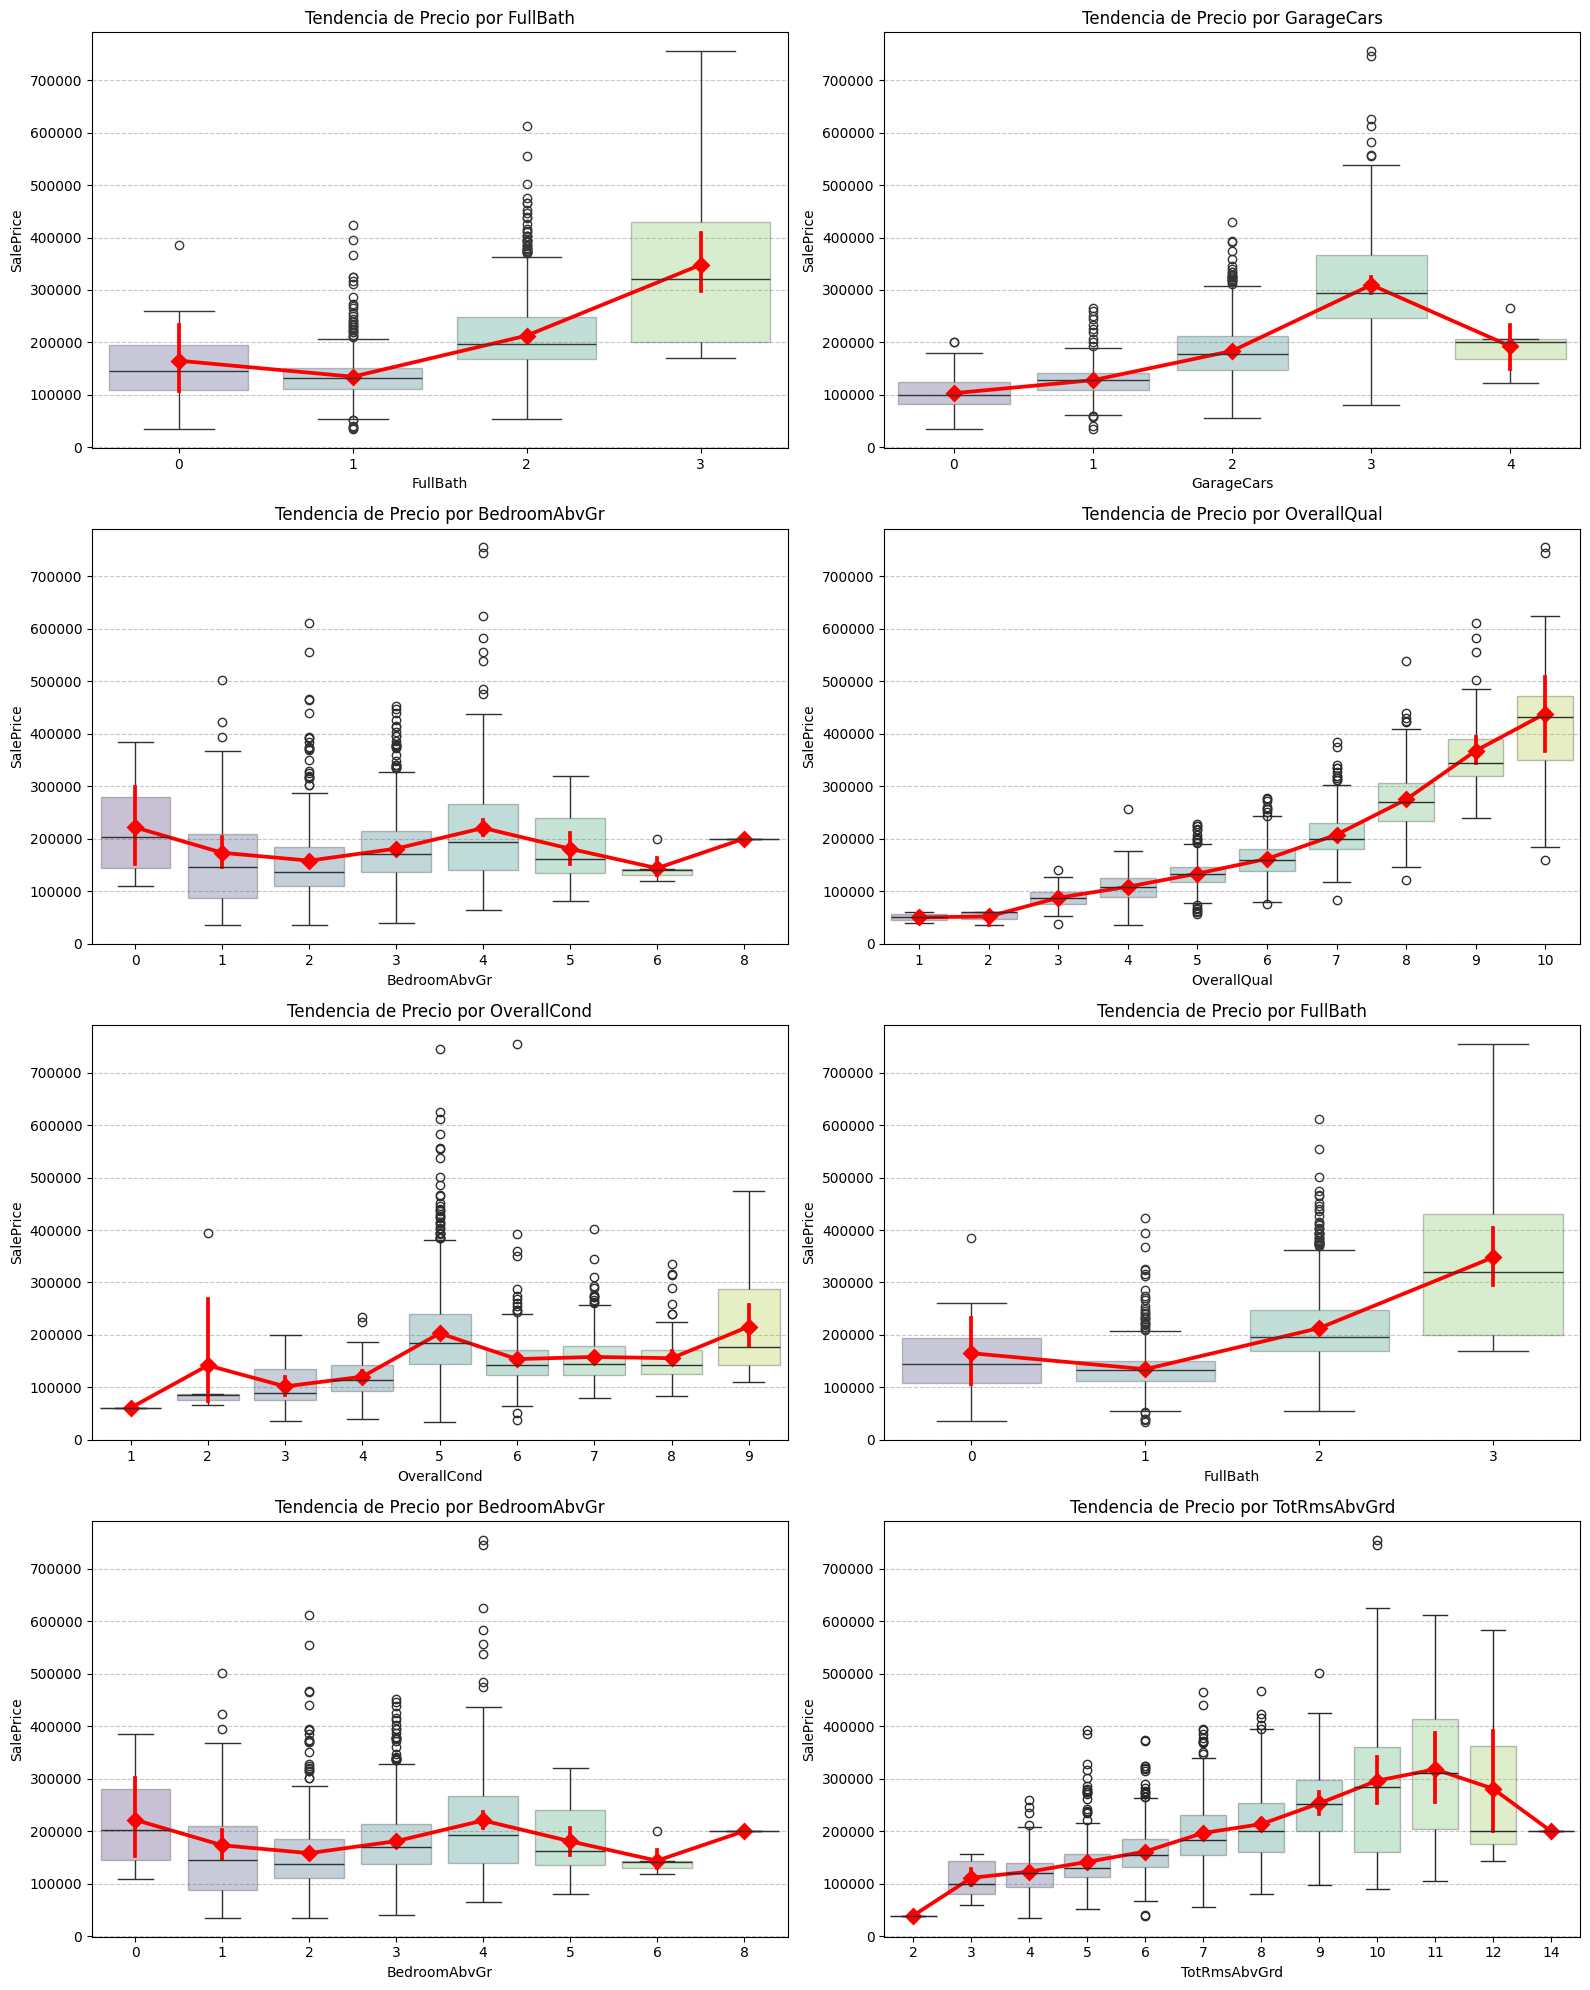

In [107]:
# Cuantitativos
    
vars_discretas = ['FullBath', 'GarageCars', 'BedroomAbvGr', 'OverallQual', 'OverallCond', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd']
n_cols = 2
n_rows = math.ceil(len(vars_discretas) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()

for i, var in enumerate(vars_discretas):
    # 1. Dibujamos las cajas para ver la dispersión
    sns.boxplot(data=df_entrenamiento, x=var, y='SalePrice', ax=axes[i], palette='viridis', boxprops=dict(alpha=.3))
    
    # 2. Dibujamos el pointplot para ver la "tendencia" del promedio
    sns.pointplot(data=df_entrenamiento, x=var, y='SalePrice', ax=axes[i], color='red', markers='D')
    
    axes[i].set_title(f'Tendencia de Precio por {var}')
    axes[i].grid(True, axis='y', linestyle='--', alpha=0.7)

# Limpiar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Cualitativas



El dataframe de prueba será el que tendremos que determinar el precio de las casas. Para el conjunto de entrenamiento lo tendremos que separar en entrenamiento y prueba.

Habiendo analizado y tratado los datos, procedemos a la aplicación de los modelos.


# Regresión lineal

In [125]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

# Separación de los datos

#x_entrenamiento, x_pruebas, y_entrenamiento, y_pruebas
gr_liv_area_entrenamiento,gr_liv_area_prueba,saleprice_entrenamiento,saleprice_pruebas = train_test_split(df_entrenamiento_filtrado[['GrLivArea']],df_entrenamiento_filtrado[['SalePrice']], test_size = 0.2, random_state=42)


modelo_lineal = LinearRegression()
modelo_lineal.fit(gr_liv_area_entrenamiento,saleprice_entrenamiento)

#Hacemos la predicción
saleprice_prediction = modelo_lineal.predict(gr_liv_area_prueba)


# MAE
mae_simple = mean_absolute_error(saleprice_pruebas,saleprice_prediction)

# RMSE
rmse_simple = np.sqrt(mean_squared_error(saleprice_pruebas,saleprice_prediction))


print(f"MODELO SIMPLE -> MAE: ${mae_simple:,.2f} | RMSE: ${rmse_simple:,.2f}")
print(f"R2 Simple: {modelo_lineal.score(gr_liv_area_entrenamiento, saleprice_entrenamiento):.4f}")


MODELO SIMPLE -> MAE: $35,005.13 | RMSE: $50,853.00
R2 Simple: 0.4932


# Regresión polinómica

In [129]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree = 2, include_bias = False)

gr_liv_area_polinomica = poly_features.fit_transform(df_entrenamiento_filtrado[['GrLivArea']])


reg_polinomica = LinearRegression()
reg_polinomica.fit(gr_liv_area_polinomica, saleprice_entrenamiento)


#predicción

saleprice_prediction_polinomica = reg_polinomica.predict()

# Evaluadores
mae_pol_reg = mean_absolute_error(saleprice_pruebas,saleprice_prediction_polinomica)
rmse_pol_reg = np.sqrt(mean_squared_error(saleprice_pruebas,saleprice_prediction_polinomica))
r2_pol_reg = r2_score(saleprice_pruebas,saleprice_prediction_polinomica)


ValueError: Found input variables with inconsistent numbers of samples: [1345, 1076]

# Arboles de decisión (Decision trees)

In [ ]:
from sklearn import tree

decision